Factor de calidad Q = 49.50
Frecuencia natural = 56.27 Hz
Tiempo de vida media = 0.1941 s
Periodo total = 0.9714 s


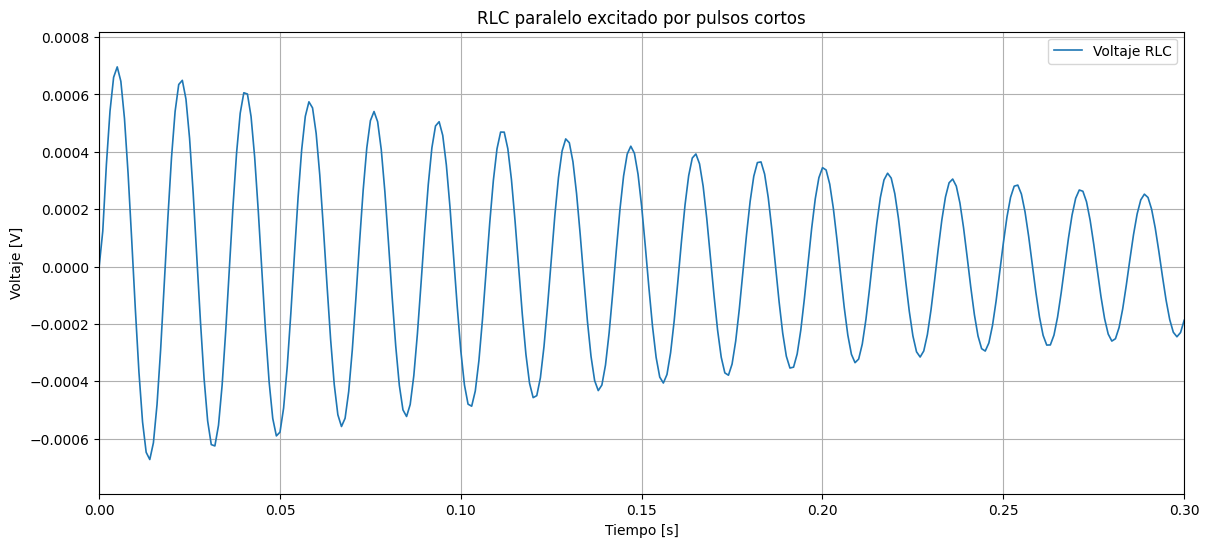

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================================================
# CIRCUITO RLC EN PARALELO
# Pulso corto de voltaje + tiempo en 0 V
# Repetido periódicamente SIN resonancia fuerte
# =========================================================

# ---------------------------------------------------------
# PARÁMETROS DEL CIRCUITO
# ---------------------------------------------------------
R = 3.5             # ohm
L = 0.2e-3          # 0.2 mH  <- CORREGIDO
C = 40e-3           # 40 mF

# ---------------------------------------------------------
# FACTOR DE CALIDAD
# ---------------------------------------------------------
Q = R * np.sqrt(C / L)

print(f"Factor de calidad Q = {Q:.2f}")

# ---------------------------------------------------------
# FRECUENCIA NATURAL
# ---------------------------------------------------------
f0 = 1 / (2 * np.pi * np.sqrt(L * C))

print(f"Frecuencia natural = {f0:.2f} Hz")

# ---------------------------------------------------------
# AMORTIGUAMIENTO
# ---------------------------------------------------------
alpha = 1 / (2 * R * C)

# tiempo de vida media
t_half = np.log(2) / alpha

print(f"Tiempo de vida media = {t_half:.4f} s")

# ---------------------------------------------------------
# CONFIGURACIÓN DEL PULSO
# ---------------------------------------------------------
Vpulso = 10               # voltios

# pulso MUY corto
duracion_pulso = 0.001    # 1 ms

# ---------------------------------------------------------
# EVITAR RESONANCIA
# dejamos bastante tiempo muerto
# ---------------------------------------------------------
T = duracion_pulso + 5  * t_half

print(f"Periodo total = {T:.4f} s")

# =========================================================
# FUENTE PERIÓDICA
# =========================================================
def fuente(t):

    tau = t % T

    if tau <= duracion_pulso:
        return Vpulso
    else:
        return 0.0

# =========================================================
# ECUACIONES DIFERENCIALES
#
# x[0] = v
# x[1] = dv/dt
#
# RLC paralelo:
#
# C*v'' + (1/R)v' + (1/L)v = Vs/C
# =========================================================
def rlc_paralelo(t, x):

    v = x[0]
    dv = x[1]

    Vs = fuente(t)

    d2v = (
        -(1/(R*C))*dv
        -(1/(L*C))*v
        + Vs/C
    )

    return [dv, d2v]

# =========================================================
# CONDICIONES INICIALES
# =========================================================
x0 = [0.0, 0.0]

# =========================================================
# TIEMPO DE SIMULACIÓN
# =========================================================
t_inicio = 0
t_final = 100

# MUCHOS puntos para ver oscilaciones rápidas
t_eval = np.linspace(t_inicio, t_final, 100000)

# =========================================================
# SOLUCIÓN NUMÉRICA
# =========================================================
sol = solve_ivp(
    rlc_paralelo,
    [t_inicio, t_final],
    x0,
    t_eval=t_eval,
    method='RK45'
)

# =========================================================
# RESULTADOS
# =========================================================
t = sol.t
v = sol.y[0]

# señal de entrada
vs = np.array([fuente(tt) for tt in t])

# =========================================================
# GRÁFICAS
# =========================================================
plt.figure(figsize=(14,6))

plt.plot(t, v, label='Voltaje RLC', linewidth=1.2)

# plt.plot(
#     t,
#     vs,
#     '--',
#     label='Pulso de entrada',
#     alpha=0.8
# )

plt.title('RLC paralelo excitado por pulsos cortos')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [V]')

plt.grid(True)
plt.legend()

# zoom inicial para ver oscilaciones
plt.xlim(0, 0.3)

plt.show()